In [634]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.signal import savgol_filter

In [548]:
##### SEFT REMINDER (MODEL 1 SIMPLE EXP SMOOTHING, 
df = pd.read_parquet("irradiance_2021_2024.parquet", engine="fastparquet")  # make sure filename is correct

# print(df.index.min(), df.index.max())
# print(df.shape[0])

2021-01-01 00:30:00 2024-12-31 23:30:00
245280


In [549]:
df.head()

,GHI,DHI,DNI,Wind Speed,Temperature,Solar Zenith Angle,Pressure,Relative Humidity,Location_ID,Elevation,City
datetime,,,,,,,,,,,
2021-01-01 00:30:00,0,0,0,1.8,6.5,169.51,968,35.09,323705,334,Phoenix
2021-01-01 01:30:00,0,0,0,1.8,6.0,163.48,968,36.34,323705,334,Phoenix
2021-01-01 02:30:00,0,0,0,1.8,5.5,152.07,968,37.37,323705,334,Phoenix
2021-01-01 03:30:00,0,0,0,1.7,5.1,139.71,968,38.47,323705,334,Phoenix
2021-01-01 04:30:00,0,0,0,1.8,4.7,127.21,969,39.97,323705,334,Phoenix


In [676]:
def fast_rolling_cv(ts, seasonal_periods=24, train_length=24*365, horizon=24*7, daylight=True):
    # seasonal_periods: 24 hours in a day
    # train_lenght: 24 hrs a day 365 days a year ~1 year of data
    # horizon how far in the future forecasting each step
    # List to store metric accross folds
    rmse_list, mae_list, smape_list, r2_list, mape_list = [], [], [], [], []

    # List to store prediction for plottings
    preds_all, test_all = [], []

    n_points = len(ts)          # Number of observation
    start = train_length        # Split length + 24 every loop

    # Rolling cv loop
    while start + horizon <= n_points:
        train = ts[start-train_length:start]
        test = ts[start:start+horizon]

        # Fit additive Holt-Winters
        model = ExponentialSmoothing(
            train,
            trend='add',
            seasonal='add', # does not work with 'mul' due to zero in GHI (night time)
            seasonal_periods=seasonal_periods,
            damped_trend=True
        ).fit(optimized=True)

        # Prediction
        pred = model.forecast(horizon)
        
        # Apply Savitzky-Golay smoothing
        if len(pred) > 3:  # window must be <= length and odd
            window = 7 if len(pred) >= 7 else len(pred) - (len(pred)+1)%2  # ensure odd
            pred = pd.Series(savgol_filter(pred, window_length=window, polyorder=2), index=pred.index)
            
        # Filter to daylight hours if requested; output accuracy similar to no 0
        if daylight:
            mask = test > 0
            test_masked = test[mask]
            pred_masked = pred[mask]
        else:
            test_masked = test
            pred_masked = pred
            
        # Save for plotting
        preds_all.append(pred)
        test_all.append(test)

        # Metrics
        rmse = np.sqrt(mean_squared_error(test, pred))
        mae = mean_absolute_error(test, pred)
        smape = 100/len(test) * np.sum(2 * np.abs(pred - test) / (np.abs(test) + np.abs(pred) + 1e-3))
        mape = np.mean(np.abs((test_masked - pred_masked) / (test_masked + 1e-3))) * 100      # division of zero increase output percentage
        r2 = r2_score(test, pred)

        # Append metric to list
        rmse_list.append(rmse)
        mae_list.append(mae)
        smape_list.append(smape)
        mape_list.append(mape)
        r2_list.append(r2)

        # Move window forward by horizon by 24 hour every fold
        start += 24

    print(f"Fast Rolling CV Results ({len(rmse_list)} folds):")
    print(f"RMSE: {np.mean(rmse_list):.2f}")
    print(f"MAE: {np.mean(mae_list):.2f}")
    print(f"SMAPE: {np.mean(smape_list):.2f}%")
    print(f"MAPE: {np.mean(mape_list):.2f}%")
    print(f"R²: {np.mean(r2_list):.4f}")
    
    # Concatenate predictions and tests for plotting
    preds_all = pd.concat(preds_all)
    test_all = pd.concat(test_all)

    return np.mean(rmse_list), np.mean(mae_list), np.mean(smape_list), np.mean(r2), np.mean(mape), preds_all, test_all

In [624]:
df_city = df[df['City'] == 'Seattle'].sort_index()
ts = df_city['GHI'].astype(float).asfreq('h').ffill()

rmse, mae, smape, preds_all, test_all, r2, mape = fast_rolling_cv(ts)

Fast Rolling CV Results (1090 folds):
RMSE: 117.36
MAE: 82.72
SMAPE: 133.89%
MAPE: 255.09%
R²: 0.4304


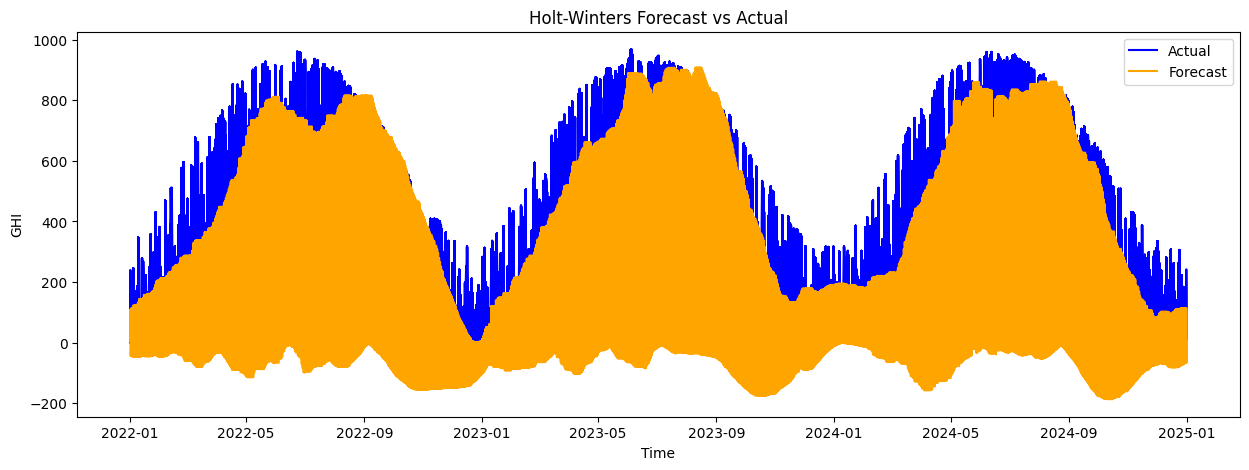

In [626]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test_all.index, test_all, label='Actual', color='blue')
plt.plot(test_all.index, preds_all, label='Forecast', color='orange')
plt.title('Holt-Winters Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('GHI')
plt.legend()
plt.show()